<center style="font-size: 30px;"> Examen </center>
<br>
<center> septiembre 30, 2026 </center>

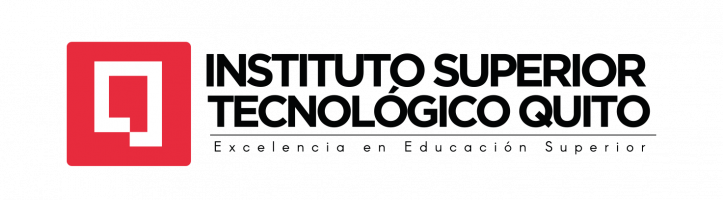

# Examen

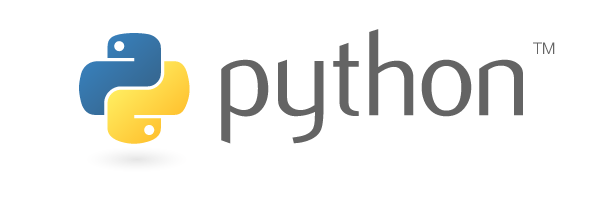

*Oswal Aaron Lopez Carrillo*

[repositorio de git](https://github.com/Aaronlc24/machine-2)

In [3]:
!pip install kagglehub

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import kagglehub
import os

In [6]:
# Descargar el dataset desde Kaggle
ruta = kagglehub.dataset_download("mirichoi0218/insurance")

print("Dataset descargado en:")
print(ruta)

100%|██████████| 16.0k/16.0k [00:00<00:00, 1.17MB/s]

Extracting files...
Dataset descargado en:
C:\Users\Aaron\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [7]:
# Mostrar los archivos descargados
print(os.listdir(ruta))

['insurance.csv']


In [8]:
# Cargar el archivo CSV
df = pd.read_csv(os.path.join(ruta, "insurance.csv"))

# Mostrar las primeras filas
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
# Cantidad de filas y columnas
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 1338
Columnas: 7


In [10]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [14]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

## 1. Carga y comprensión de los datos


In [15]:
# Revisar valores nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
# Porcentaje de valores nulos
(df.isnull().sum() / len(df)) * 100

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [17]:
# Cantidad de registros duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 1


In [18]:
# Eliminar registros duplicados
df = df.drop_duplicates()

print("Filas después de eliminar duplicados:", len(df))

Filas después de eliminar duplicados: 1337


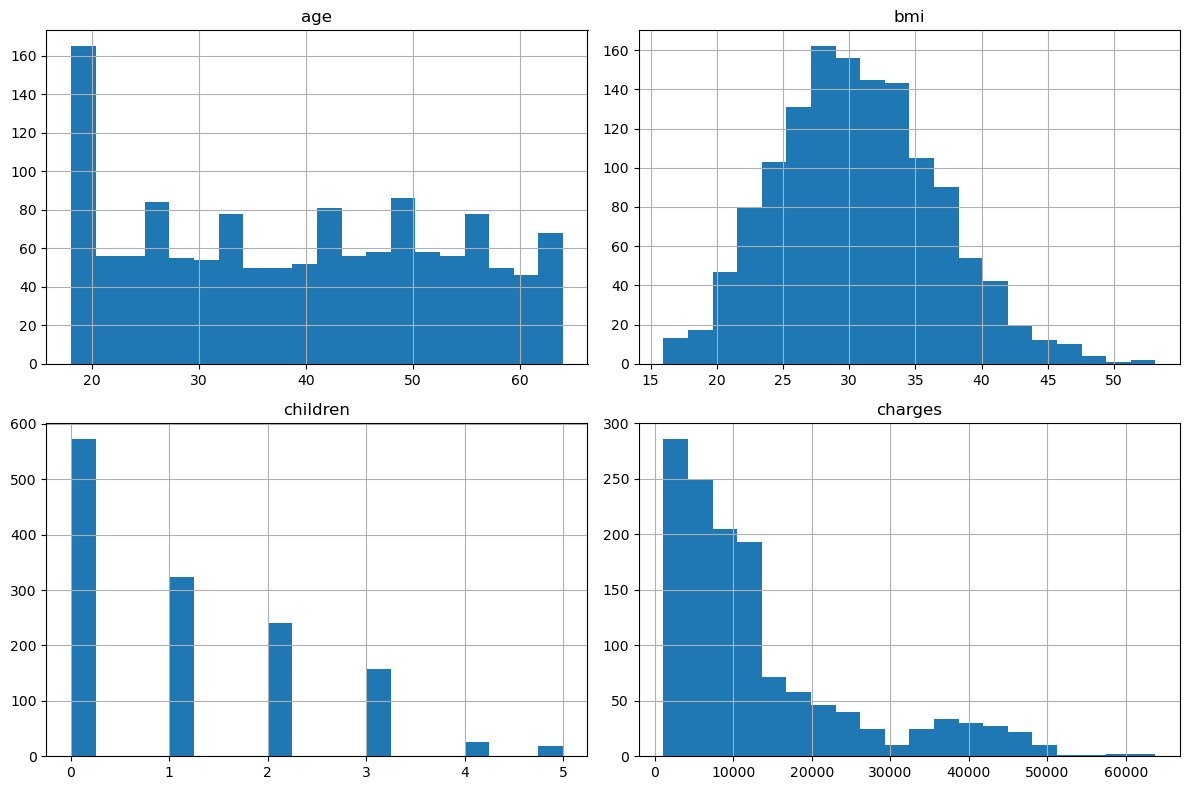

In [19]:
# Histogramas de variables numéricas
df.hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

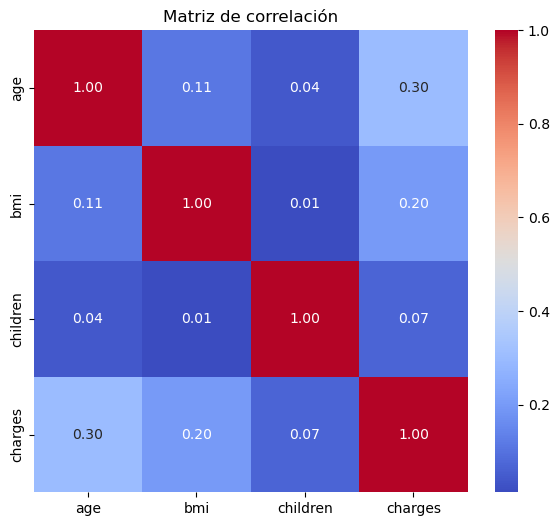

In [23]:
# Seleccionar únicamente variables numéricas
df_numeric = df.select_dtypes(include=np.number)

# Matriz de correlación
correlacion = df_numeric.corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

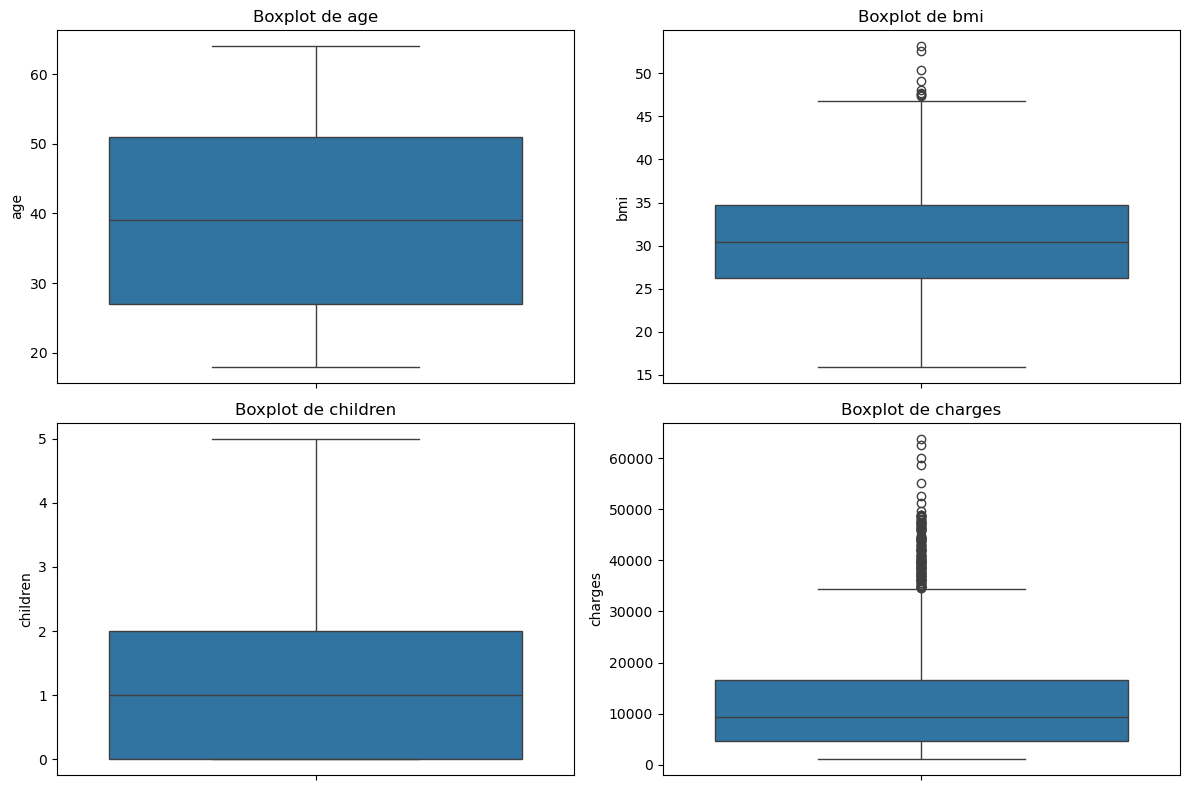

In [24]:
# Variables numéricas que vamos a analizar
variables_numericas = ['age', 'bmi', 'children', 'charges']

# Crear los gráficos
plt.figure(figsize=(12, 8))

for i, variable in enumerate(variables_numericas):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[variable])
    plt.title(f'Boxplot de {variable}')
    plt.ylabel(variable)

plt.tight_layout()
plt.show()

In [27]:
# Función para detectar valores atípicos mediante IQR

def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]
    
    return outliers, limite_inferior, limite_superior

In [28]:
# Analizar cada variable numérica

for variable in variables_numericas:
    
    outliers, limite_inf, limite_sup = detectar_outliers(df, variable)
    
    print(f"\nVariable: {variable}")
    print(f"Límite inferior: {limite_inf:.2f}")
    print(f"Límite superior: {limite_sup:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")


Variable: age
Límite inferior: -9.00
Límite superior: 87.00
Cantidad de outliers: 0

Variable: bmi
Límite inferior: 13.67
Límite superior: 47.32
Cantidad de outliers: 9

Variable: children
Límite inferior: -3.00
Límite superior: 5.00
Cantidad de outliers: 0

Variable: charges
Límite inferior: -13120.72
Límite superior: 34524.78
Cantidad de outliers: 139


In [29]:
# Obtener los valores atípicos de charges

outliers_charges, limite_inf, limite_sup = detectar_outliers(df, 'charges')

print("Cantidad de outliers en charges:", len(outliers_charges))

outliers_charges[['age', 'bmi', 'smoker', 'charges']].head(20)

Cantidad de outliers en charges: 139


,age,bmi,smoker,charges
14,27,42.130,yes,39611.75770
19,30,35.300,yes,36837.46700
23,34,31.920,yes,37701.87680
29,31,36.300,yes,38711.00000
30,22,35.600,yes,35585.57600
34,28,36.400,yes,51194.55914
38,35,36.670,yes,39774.27630
39,60,39.900,yes,48173.36100
49,36,35.200,yes,38709.17600
53,36,34.430,yes,37742.57570


## 3. DETECCION DE VALORES ATIPICOS

In [32]:
# Separar variables independientes y variable objetivo

X = df.drop('charges', axis=1)
y = df['charges']

print("Variables independientes:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Variables independientes:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Variable objetivo:
charges


In [33]:
# Variables numéricas
variables_numericas = ['age', 'bmi', 'children']

# Variables categóricas
variables_categoricas = ['sex', 'smoker', 'region']

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['age', 'bmi', 'children']

Variables categóricas:
['sex', 'smoker', 'region']


In [34]:
# Transformaciones para cada tipo de variable

preprocesamiento = ColumnTransformer(
    transformers=[
        ('numericas', StandardScaler(), variables_numericas),
        ('categoricas', OneHotEncoder(drop='first', handle_unknown='ignore'), variables_categoricas)
    ]
)

print("Preprocesamiento preparado correctamente.")

Preprocesamiento preparado correctamente.


## 4. validacion de datos

In [35]:
# Dividir los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1069, 6)
Datos de prueba: (268, 6)


## Estandarizamos

In [37]:
StandardScaler()

,copy,True
,with_mean,True
,with_std,True


In [38]:
# Estadísticas antes de la estandarización

X_train[variables_numericas].describe()

,age,bmi,children
count,1069.000000,1069.000000,1069.000000
mean,39.198316,30.540426,1.084191
std,13.998594,6.051841,1.194723
min,18.000000,15.960000,0.000000
25%,27.000000,26.180000,0.000000
50%,39.000000,30.200000,1.000000
75%,51.000000,34.430000,2.000000
max,64.000000,53.130000,5.000000


In [39]:
# Correlación de las variables numéricas con charges

correlacion_charges = df_numeric.corr()['charges'].sort_values(
    ascending=False
)

print(correlacion_charges)

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


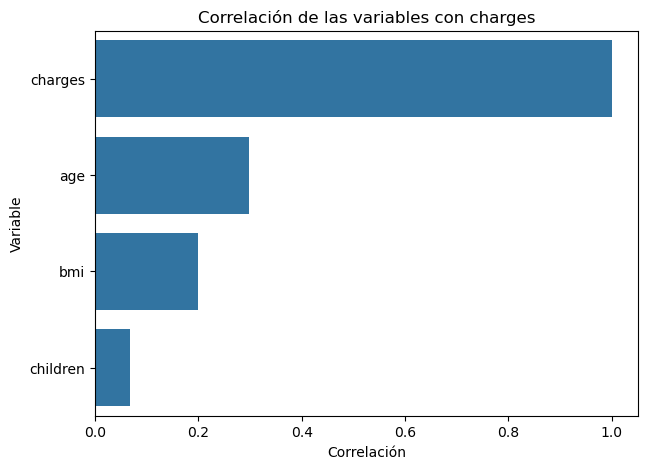

In [41]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=correlacion_charges.values,
    y=correlacion_charges.index
)

plt.title("Correlación de las variables con charges")
plt.xlabel("Correlación")
plt.ylabel("Variable")

plt.show()

In [42]:
# Crear el pipeline del modelo

modelo = Pipeline(
    steps=[
        ('preprocesamiento', preprocesamiento),
        ('regresion', LinearRegression())
    ]
)

print("Pipeline creado correctamente.")

Pipeline creado correctamente.


## Entrenamiento

In [43]:
# Entrenar el modelo

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [44]:
# Realizar predicciones sobre los datos de prueba

y_pred = modelo.predict(X_test)

print("Primeras 10 predicciones:")
print(y_pred[:10])

Primeras 10 predicciones:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706 13149.72235307 30446.76067941  1453.28881259
 10633.01840233 11318.94379361]


In [45]:
# Calcular métricas de evaluación

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Resultados del modelo")
print("---------------------")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

Resultados del modelo
---------------------
MAE:  4177.05
RMSE: 5956.34
R²:   0.8069


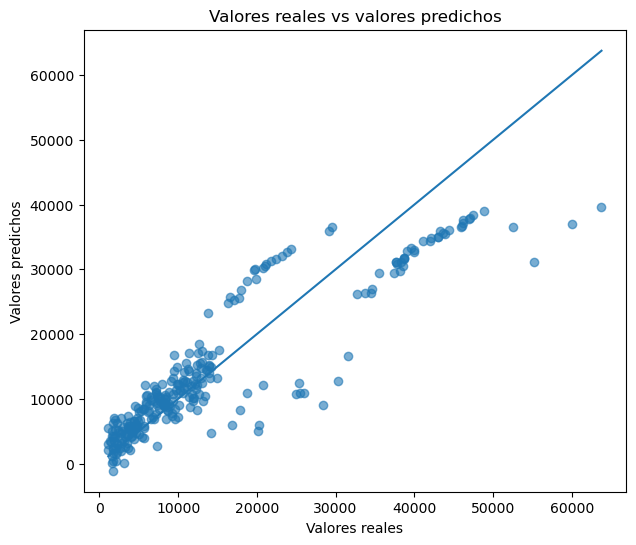

In [52]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs valores predichos")

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [53]:
# Crear una nueva observación

nuevo_paciente = pd.DataFrame({
    'age': [35],
    'sex': ['male'],
    'bmi': [28.5],
    'children': [2],
    'smoker': ['no'],
    'region': ['southeast']
})

nuevo_paciente

,age,sex,bmi,children,smoker,region
0,35,male,28.5,2,no,southeast


In [54]:
# Predecir los gastos médicos

prediccion = modelo.predict(nuevo_paciente)

print(f"Gastos médicos estimados: ${prediccion[0]:.2f}")

Gastos médicos estimados: $6803.27


## Conclusión

Mediante esta actividad se logró desarrollar un proceso completo de Machine Learning utilizando un modelo de Regresión Lineal Múltiple para estimar los gastos médicos. Se aprendió la importancia de realizar un análisis exploratorio de los datos antes de entrenar un modelo, así como identificar valores atípicos, preparar las variables y transformar los datos correctamente.

También se comprendió la importancia de dividir los datos en entrenamiento y prueba para evaluar el modelo con información que no fue utilizada durante su aprendizaje. Las métricas obtenidas permitieron conocer el comportamiento y el nivel de error de las predicciones realizadas.

Finalmente, esta actividad permitió reforzar los conocimientos sobre el desarrollo de modelos de Machine Learning en Python y Jupyter, demostrando que el análisis y preparación de los datos son etapas fundamentales para obtener resultados confiables. Además, permitió comprender cómo un modelo de regresión puede utilizar diferentes características de una persona para realizar una estimación de sus gastos médicos.


## Bibliografía 

scikit-learn: machine learning in Python — scikit-learn 1.9.1 documentation. (2026). Scikit-Learn.Org. https://scikit-learn.org/stable/index.html
‌